In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation
import anthropic
from dotenv import load_dotenv
import os

load_dotenv(os.path.expanduser('~/.env_anthropic'))
client = anthropic.Anthropic(api_key=os.environ.get('ANTHROPIC_API_KEY'))

print("Всё импортировано!")

Всё импортировано!


In [3]:
import requests
from xml.etree import ElementTree
import time

def get_headlines(query, max_results=20):
    url = f"https://news.google.com/rss/search?q={query}&hl=en-US&gl=US&ceid=US:en"
    response = requests.get(url)
    root = ElementTree.fromstring(response.content)
    
    headlines = []
    for item in root.findall('.//item')[:max_results]:
        title = item.find('title').text
        pub_date = item.find('pubDate').text
        headlines.append({'headline': title, 'date': pub_date, 'query': query})
    
    return headlines

queries = [
    'AI education schools students',
    'artificial intelligence classroom teachers',
    'AI learning children policy'
]

all_headlines = []
for query in queries:
    results = get_headlines(query, max_results=50)
    all_headlines.extend(results)
    time.sleep(1)

df = pd.DataFrame(all_headlines).drop_duplicates(subset='headline')
print(f"Загружено заголовков: {len(df)}")
df.head()

Загружено заголовков: 143


,headline,date,query
0,Opinion | What Schools Are Forgetting in Their...,"Wed, 20 May 2026 19:00:04 GMT",AI education schools students
1,Amityville police investigating 'disturbing' a...,"Fri, 22 May 2026 23:40:20 GMT",AI education schools students
2,Overworked and understaffed: Special ed teache...,"Wed, 20 May 2026 09:00:00 GMT",AI education schools students
3,From AI Policies To AI Literacy In Education -...,"Thu, 21 May 2026 00:15:44 GMT",AI education schools students
4,The Hudson School: An Independent Education Bu...,"Wed, 20 May 2026 14:00:00 GMT",AI education schools students


In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# Подготавливаем текст
headlines_list = df['headline'].tolist()

# TF-IDF векторизация — превращаем слова в числа
vectorizer = TfidfVectorizer(
    max_features=500,
    stop_words='english',
    ngram_range=(1, 2)  # учитываем пары слов тоже
)

X = vectorizer.fit_transform(headlines_list)
print(f"Матрица: {X.shape[0]} заголовков × {X.shape[1]} слов")

# LDA — находим 5 тем
lda = LatentDirichletAllocation(n_components=5, random_state=42)
lda.fit(X)

# Показываем топ слова для каждой темы
feature_names = vectorizer.get_feature_names_out()
print("\nТОП ТЕМЫ:\n")
for i, topic in enumerate(lda.components_):
    top_words = [feature_names[j] for j in topic.argsort()[-8:]][::-1]
    print(f"Тема {i+1}: {', '.join(top_words)}")

Матрица: 143 заголовков × 500 слов

ТОП ТЕМЫ:

Тема 1: education, ai, trends, pennsylvania, ai education, stanford, child trends, schools
Тема 2: university, ai, education, intelligence, artificial, artificial intelligence, learning, school
Тема 3: ai, children, schools, education, magazine, 12, ai literacy, literacy
Тема 4: new, teachers, ai, classroom, times, york times, york, new york
Тема 5: schools, ai, students, ai schools, opinion, week, education week, education


In [5]:
# Присваиваем каждому заголовку его главную тему
topic_assignments = lda.transform(X).argmax(axis=1)
df['topic'] = topic_assignments + 1  # нумерация с 1

topic_labels = {
    1: 'Academic & Regional Policy',
    2: 'Higher Education',
    3: 'Early Childhood & Literacy',
    4: 'Teachers & Mainstream Media',
    5: 'Students & EdWeek'
}
df['topic_label'] = df['topic'].map(topic_labels)

# Показываем примеры из каждой темы
for topic_num in range(1, 6):
    examples = df[df['topic'] == topic_num]['headline'].head(3).tolist()
    print(f"\n{'='*60}")
    print(f"Тема {topic_num}: {topic_labels[topic_num]}")
    for ex in examples:
        print(f"  • {ex[:80]}")


Тема 1: Academic & Regional Policy
  • Amityville police investigating 'disturbing' allegations of AI, social media mis
  • AI in Education Legislation: 2026 State Policy Trends - MultiState
  • El Paso schools work to adapt to rise of AI in education: policies, programs and

Тема 2: Higher Education
  • The Hudson School: An Independent Education Built for the Age of AI (Sponsored) 
  • Staff at Rochester charter school weigh in on using AI to create lesson plans - 
  • UC Berkeley Law School restricts use of AI by students - ABA Journal

Тема 3: Early Childhood & Literacy
  • From AI Policies To AI Literacy In Education - Forbes
  • Naval Postgraduate School, private sector partner to improve AI education - Fede
  • Can AI help more high schools teach computer programming? A Louisiana college is

Тема 4: Teachers & Mainstream Media
  • Overworked and understaffed: Special ed teachers turn to AI for help - NPR
  • Putting educators at the center of AI learning - blog.google
  • The r

In [14]:
def classify_topic(headline):
    message = client.messages.create(
        model="claude-haiku-4-5-20251001",
        max_tokens=50,
        temperature=0,
        messages=[{
            "role": "user",
            "content": f"""Classify this headline into ONE topic:
1. Policy & Regulation
2. Classroom & Teachers  
3. Students & Learning
4. Safety & Ethics
5. Early Childhood

Headline: "{headline}"
Reply with ONLY the number and topic name, nothing else."""
        }]
    )
    return message.content[0].text.strip()

# Тестируем на 5 примерах
test_headlines = df['headline'].head(5).tolist()
for h in test_headlines:
    topic = classify_topic(h)
    print(f"{topic}")
    print(f"  → {h[:70]}\n")
    time.sleep(0.3)

1. Policy & Regulation
  → Opinion | What Schools Are Forgetting in Their Race to Embrace A.I. - 

4. Safety & Ethics
  → Amityville police investigating 'disturbing' allegations of AI, social

2. Classroom & Teachers
  → Overworked and understaffed: Special ed teachers turn to AI for help -

1. Policy & Regulation
  → From AI Policies To AI Literacy In Education - Forbes

1. Policy & Regulation
  → The Hudson School: An Independent Education Built for the Age of AI (S



In [13]:
from dotenv import load_dotenv
import os
import anthropic

load_dotenv(os.path.expanduser('~/.env_anthropic'))
client = anthropic.Anthropic(api_key=os.environ.get('ANTHROPIC_API_KEY'))

def classify_topic(headline):
    message = client.messages.create(
        model="claude-haiku-4-5-20251001",
        max_tokens=50,
        temperature=0,
        messages=[{
            "role": "user",
            "content": f"""Classify this headline into ONE topic:
1. Policy & Regulation
2. Classroom & Teachers  
3. Students & Learning
4. Safety & Ethics
5. Early Childhood

Headline: "{headline}"
Reply with ONLY the number and topic name, nothing else."""
        }]
    )
    return message.content[0].text.strip()

test_headlines = df['headline'].head(5).tolist()
for h in test_headlines:
    topic = classify_topic(h)
    print(f"{topic}")
    print(f"  → {h[:70]}\n")
    time.sleep(0.3)

1. Policy & Regulation
  → Opinion | What Schools Are Forgetting in Their Race to Embrace A.I. - 

4. Safety & Ethics
  → Amityville police investigating 'disturbing' allegations of AI, social

2. Classroom & Teachers
  → Overworked and understaffed: Special ed teachers turn to AI for help -

1. Policy & Regulation
  → From AI Policies To AI Literacy In Education - Forbes

1. Policy & Regulation
  → The Hudson School: An Independent Education Built for the Age of AI (S



In [12]:
import os
import anthropic

client = anthropic.Anthropic(api_key=os.environ.get('ANTHROPIC_API_KEY'))

# Быстрая проверка
test = client.messages.create(
    model="claude-haiku-4-5-20251001",
    max_tokens=20,
    messages=[{"role": "user", "content": "say ok"}]
)
print(test.content[0].text)

ok


In [11]:
import subprocess
result = subprocess.run(['cat', os.path.expanduser('~/.env_anthropic')], 
                      capture_output=True, text=True)
key_line = result.stdout.strip()
key = key_line.split('=', 1)[1]
os.environ['ANTHROPIC_API_KEY'] = key

client = anthropic.Anthropic(api_key=key)
test = client.messages.create(
    model="claude-haiku-4-5-20251001",
    max_tokens=20,
    messages=[{"role": "user", "content": "say ok"}]
)
print(test.content[0].text)

ok


In [15]:
print("Классифицируем 143 заголовка...")

claude_topics = []
for i, headline in enumerate(df['headline'].tolist()):
    topic = classify_topic(headline)
    claude_topics.append(topic)
    if i % 20 == 0:
        print(f"  {i}/143 готово...")
    time.sleep(0.3)

df['claude_topic'] = claude_topics
print("\nГотово! Распределение по темам:")
print(df['claude_topic'].value_counts())

Классифицируем 143 заголовка...
  0/143 готово...
  20/143 готово...
  40/143 готово...
  60/143 готово...
  80/143 готово...
  100/143 готово...
  120/143 готово...
  140/143 готово...

Готово! Распределение по темам:
claude_topic
1. Policy & Regulation     67
2. Classroom & Teachers    34
3. Students & Learning     30
4. Safety & Ethics         10
5. Early Childhood          2
Name: count, dtype: int64


In [16]:
# Извлекаем издание из заголовка (после последнего дефиса)
df['publication'] = df['headline'].str.extract(r'-\s*([^-]+)$')
df['publication'] = df['publication'].str.strip()

# Cross-reference: издание × тема
cross_tab = pd.crosstab(df['publication'], df['claude_topic'])

# Показываем только издания с 3+ публикациями
active_pubs = cross_tab[cross_tab.sum(axis=1) >= 3]
print("Издания с 3+ заголовками:\n")
print(active_pubs.to_string())

Издания с 3+ заголовками:

claude_topic        1. Policy & Regulation  2. Classroom & Teachers  3. Students & Learning  4. Safety & Ethics  5. Early Childhood
publication                                                                                                                        
12 Dive                                  0                        2                       1                   0                   0
Brookings                                1                        0                       2                   0                   0
Child Trends                             2                        1                       0                   0                   0
EdSource                                 3                        1                       2                   0                   0
EdTech Magazine                          1                        2                       1                   0                   0
Education Week                           2       

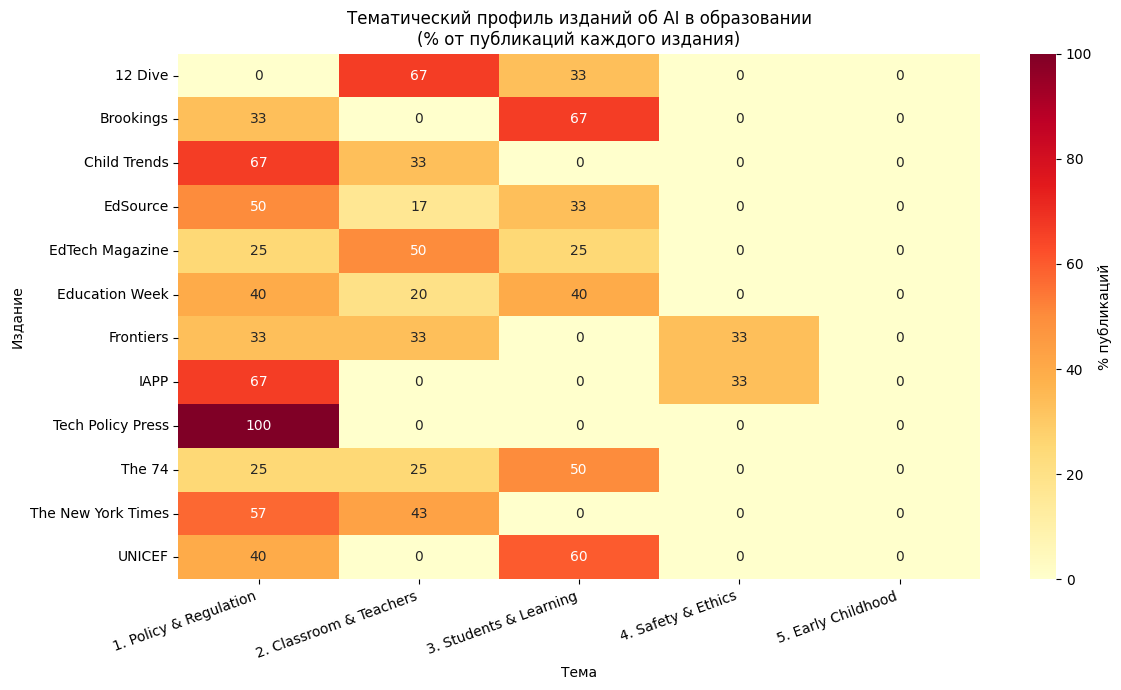

In [17]:
import seaborn as sns

fig, ax = plt.subplots(figsize=(12, 7))

# Нормализуем по строкам - % от каждого издания
active_pubs_pct = active_pubs.div(active_pubs.sum(axis=1), axis=0) * 100

sns.heatmap(active_pubs_pct, 
            annot=True, fmt='.0f', 
            cmap='YlOrRd',
            ax=ax,
            cbar_kws={'label': '% публикаций'})

ax.set_title('Тематический профиль изданий об AI в образовании\n(% от публикаций каждого издания)')
ax.set_xlabel('Тема')
ax.set_ylabel('Издание')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()